In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df_klaim = pd.read_csv('dataset/Data_Klaim.csv')
df_polis = pd.read_csv('dataset/Data_Polis.csv')
df_klaim.head(2)

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6143947.68,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,82309522.45,Malaysia


In [28]:
df_polis.head(3)

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA


1. DATA CLEANING

In [29]:
#checking missing value df_klaim
(df_klaim.isnull().sum() / len(df_klaim)) * 100

Claim ID                         0.000000
Nomor Polis                      0.000000
Reimburse/Cashless               0.000000
Inpatient/Outpatient             0.799654
ICD Diagnosis                    0.129674
ICD Description                  0.129674
Status Klaim                     0.000000
Tanggal Pembayaran Klaim         0.799654
Tanggal Pasien Masuk RS          0.000000
Tanggal Pasien Keluar RS         0.000000
Nominal Klaim Yang Disetujui     0.000000
Nominal Biaya RS Yang Terjadi    0.000000
Lokasi RS                        0.151286
dtype: float64

In [30]:
df_klaim.isna().sum()

Claim ID                          0
Nomor Polis                       0
Reimburse/Cashless                0
Inpatient/Outpatient             37
ICD Diagnosis                     6
ICD Description                   6
Status Klaim                      0
Tanggal Pembayaran Klaim         37
Tanggal Pasien Masuk RS           0
Tanggal Pasien Keluar RS          0
Nominal Klaim Yang Disetujui      0
Nominal Biaya RS Yang Terjadi     0
Lokasi RS                         7
dtype: int64

In [31]:
df_klaim[df_klaim["Tanggal Pembayaran Klaim"].isna()].head(4)


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,1.389364e+08,1.389364e+08,Singapore
5,C-0006-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-07-18,2024-07-18,1.360160e+08,1.368552e+08,Singapore
6,C-0007-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-27,2024-06-27,1.341925e+08,1.347333e+08,Singapore
7,C-0008-M,POL-0566,R,OP,C90.0,Multiple myeloma,PAID,NaN,2024-06-19,2024-06-19,5.398718e+08,3.164563e+08,Singapore


In [32]:
#mengambil kolom yang memiliki baris null di df_klaim
kolom_null_klaim = [x for x in df_klaim.columns if df_klaim[x].isna().any()]
kolom_null_klaim    

['Inpatient/Outpatient',
 'ICD Diagnosis',
 'ICD Description',
 'Tanggal Pembayaran Klaim',
 'Lokasi RS']

In [33]:
#checking missing value df_polis
df_polis.isna().sum()

Nomor Polis              0
Plan Code                0
Gender                   0
Tanggal Lahir            0
Tanggal Efektif Polis    0
Domisili                 0
dtype: int64

In [34]:
#checking duplcated value
df_polis.duplicated().sum()
df_klaim.duplicated().sum()

np.int64(0)

Simulasi mengatasi missing value:
- 'Tanggal Pembayaran klaim' -> Imputasi dengan "Median Lag" -> Ambil semua data yang lengkap (punya tanggal keluar RS & tanggal bayar).
Hitung selisih hari (Lag) = Tanggal Pembayaran - Tanggal Keluar RS

- 'Inpatient/Outpatient' -> diisi berdasarkan selisih tgl keluar - tgl masuk -> kalau > 0 maka Inpatient, kalo = 0 maka outpatient

- 'ICD Diagnosis'  -> Standar WHO ICD-10 (International Classification of Diseases) isi dgn 'R69' artinya Unknown and unspecified causes of morbidity (Penyebab kesakitan yang tidak diketahui/tidak spesifik).

- 'ICD Description' -> diisi "Unknown". Ini membuat model mengerti bahwa "tidak ada diagnosa" adalah sebuah kategori risiko tersendiri.

-'lokasi RS' -> isi dengan 'OTHER'

In [35]:
df_klaim.dtypes

Claim ID                             str
Nomor Polis                          str
Reimburse/Cashless                   str
Inpatient/Outpatient                 str
ICD Diagnosis                        str
ICD Description                      str
Status Klaim                         str
Tanggal Pembayaran Klaim             str
Tanggal Pasien Masuk RS              str
Tanggal Pasien Keluar RS             str
Nominal Klaim Yang Disetujui     float64
Nominal Biaya RS Yang Terjadi    float64
Lokasi RS                            str
dtype: object

In [36]:
#SOLVING MISSING VALUE
df_klaim_cleaned = df_klaim.copy()

'''Pastikan kolom tanggal bertipe datetime, bukan object/string'''
cols_date = ['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS']
for col in cols_date:
    df_klaim_cleaned[col] = pd.to_datetime(df_klaim_cleaned[col], errors='coerce')

# 1. IMPUTASI TANGGAL PEMBAYARAN KLAIM (MEDIAN LAG)
''' a. Hitung Lag (selisih hari) pada data yang LENGKAP saja '''
valid_data = df_klaim_cleaned.dropna(subset=['Tanggal Pembayaran Klaim', 'Tanggal Pasien Keluar RS'])
lag_days = (valid_data['Tanggal Pembayaran Klaim'] - valid_data['Tanggal Pasien Keluar RS']).dt.days

''' b. Ambil nilai tengah (Median)'''
median_lag = lag_days.median()
print(f"Median Lag yang ditemukan: {median_lag} hari")

''' c. Isi Tanggal Pembayaran yang NULL = Tanggal Keluar + Median Lag '''
mask_null_pay = df_klaim_cleaned['Tanggal Pembayaran Klaim'].isnull()
df_klaim_cleaned.loc[mask_null_pay, 'Tanggal Pembayaran Klaim'] = (
    df_klaim_cleaned.loc[mask_null_pay, 'Tanggal Pasien Keluar RS'] + pd.to_timedelta(median_lag, unit='D')
)

# 2. IMPUTASI INPATIENT/OUTPATIENT 
# Hitung durasi rawat (Keluar - Masuk)
durasi_rawat = (df_klaim_cleaned['Tanggal Pasien Keluar RS'] - df_klaim_cleaned['Tanggal Pasien Masuk RS']).dt.days

# Logic: Jika durasi > 0 -> Inpatient, Jika 0 -> Outpatient
# isi yang NULL saja
mask_null_io = df_klaim_cleaned['Inpatient/Outpatient'].isnull()
df_klaim_cleaned.loc[mask_null_io, 'Inpatient/Outpatient'] = np.where(
    durasi_rawat[mask_null_io] > 0, 'Inpatient', 'Outpatient'
)

# 3. IMPUTASI KATEGORIKAL (ICD & LOKASI)
# ICD Diagnosis -> R69 (Unknown Cause)
df_klaim_cleaned['ICD Diagnosis'] = df_klaim_cleaned['ICD Diagnosis'].fillna('R69')

# ICD Description -> Unknown
df_klaim_cleaned['ICD Description'] = df_klaim_cleaned['ICD Description'].fillna('Unknown')

# Lokasi RS -> OTHER
df_klaim_cleaned['Lokasi RS'] = df_klaim_cleaned['Lokasi RS'].fillna('OTHER')

print("\nSisa Missing Value setelah cleaning:")
print(df_klaim_cleaned.isnull().sum())


Median Lag yang ditemukan: 61.0 hari

Sisa Missing Value setelah cleaning:
Claim ID                         0
Nomor Polis                      0
Reimburse/Cashless               0
Inpatient/Outpatient             0
ICD Diagnosis                    0
ICD Description                  0
Status Klaim                     0
Tanggal Pembayaran Klaim         0
Tanggal Pasien Masuk RS          0
Tanggal Pasien Keluar RS         0
Nominal Klaim Yang Disetujui     0
Nominal Biaya RS Yang Terjadi    0
Lokasi RS                        0
dtype: int64


In [37]:
print(f"Cek tipe data: \n{df_klaim_cleaned.dtypes}")
print(f"\nCek duplikat: \n{df_klaim_cleaned.duplicated().sum()}")

Cek tipe data: 
Claim ID                                    str
Nomor Polis                                 str
Reimburse/Cashless                          str
Inpatient/Outpatient                        str
ICD Diagnosis                               str
ICD Description                             str
Status Klaim                                str
Tanggal Pembayaran Klaim         datetime64[us]
Tanggal Pasien Masuk RS          datetime64[us]
Tanggal Pasien Keluar RS         datetime64[us]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                   str
dtype: object

Cek duplikat: 
0


In [38]:
df_polis.info()

<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Nomor Polis            4096 non-null   str  
 1   Plan Code              4096 non-null   str  
 2   Gender                 4096 non-null   str  
 3   Tanggal Lahir          4096 non-null   int64
 4   Tanggal Efektif Polis  4096 non-null   int64
 5   Domisili               4096 non-null   str  
dtypes: int64(2), str(4)
memory usage: 192.1 KB


In [39]:
df_polis_cleaned = df_polis.copy()

In [40]:
date_cols = ["Tanggal Lahir", "Tanggal Efektif Polis"]

for col in date_cols:
    df_polis_cleaned[col] = pd.to_datetime(df_polis_cleaned[col], format="%Y%m%d", errors="coerce")

df_polis_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Nomor Polis            4096 non-null   str           
 1   Plan Code              4096 non-null   str           
 2   Gender                 4096 non-null   str           
 3   Tanggal Lahir          4096 non-null   datetime64[us]
 4   Tanggal Efektif Polis  4096 non-null   datetime64[us]
 5   Domisili               4096 non-null   str           
dtypes: datetime64[us](2), str(4)
memory usage: 192.1 KB


2. EDA

In [41]:
# Merge: Left join agar semua data klaim terambil, ditambah info polisnya
df_final = df_klaim_cleaned.merge(df_polis_cleaned, on='Nomor Polis', how='left')

In [42]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Claim ID                       4627 non-null   str           
 1   Nomor Polis                    4627 non-null   str           
 2   Reimburse/Cashless             4627 non-null   str           
 3   Inpatient/Outpatient           4627 non-null   str           
 4   ICD Diagnosis                  4627 non-null   str           
 5   ICD Description                4627 non-null   str           
 6   Status Klaim                   4627 non-null   str           
 7   Tanggal Pembayaran Klaim       4627 non-null   datetime64[us]
 8   Tanggal Pasien Masuk RS        4627 non-null   datetime64[us]
 9   Tanggal Pasien Keluar RS       4627 non-null   datetime64[us]
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64       
 11  Nominal Biaya RS Yang Terjad

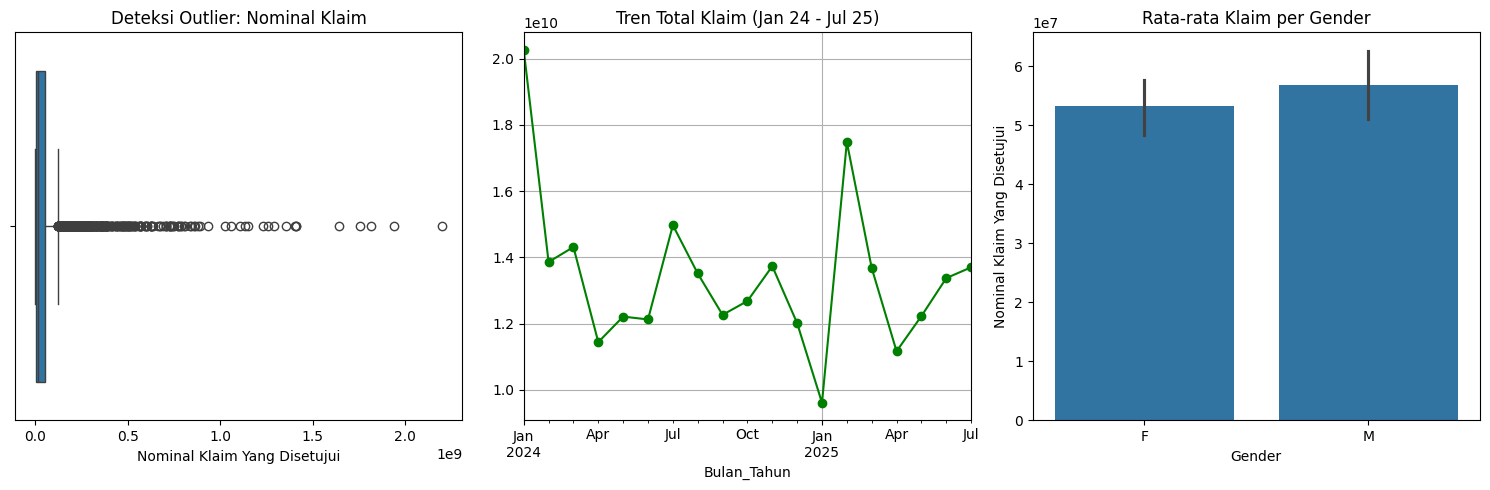

In [43]:
#Identifikasi Outlier & Visualisasi Tren
#Fokus: Melihat distribusi data "uang" dan memvalidasi tren kenaikan.

plt.figure(figsize=(15, 5))

# A. Deteksi Outlier pada Nominal Klaim (Boxplot)
plt.subplot(1, 3, 1)
sns.boxplot(x=df_final['Nominal Klaim Yang Disetujui'])
plt.title('Deteksi Outlier: Nominal Klaim')

# B. Tren Total Klaim per Bulan (Line Plot)
# Validasi kenaikan 25.5%
df_final['Bulan_Tahun'] = df_final['Tanggal Pasien Masuk RS'].dt.to_period('M')
trend_data = df_final.groupby('Bulan_Tahun')['Nominal Klaim Yang Disetujui'].sum()

plt.subplot(1, 3, 2)
trend_data.plot(kind='line', marker='o', color='green')
plt.title('Tren Total Klaim (Jan 24 - Jul 25)')
plt.grid(True)

# C. Hubungan Gender vs Rata-rata Klaim (Bar Plot)
plt.subplot(1, 3, 3)
sns.barplot(data=df_final, x='Gender', y='Nominal Klaim Yang Disetujui', estimator=np.mean)
plt.title('Rata-rata Klaim per Gender')

plt.tight_layout()
plt.show()

1. Outlier:  banyak outliers = klaim jumbo. Jangan dihapus, tapi di-log transform tuk Menormalkan Distribusi dan Meredam Skala Ekstrem. tidak dihapus karena:

    - Data Valid, Bukan Error: Dalam asuransi, klaim jumbo (titik hitam di boxplot) adalah kejadian nyata, bukan kesalahan input.

    - Risiko Sebenarnya: Menghapusnya akan membuat analisis bias. ini akan meremehkan risiko finansial perusahaan karena "membutakan" model terhadap potensi kerugian besar yang sewaktu-waktu bisa terjadi.

2. Tren: grafik garis menanjak di 2025 (sesuai dgn deskripsi kondisi)

3. Faktor: Pria dan Wanita tdk memiliki beban klaim yang berbeda signifikan.

CEK KAUSALITAS / FAKTOR2 YG BERHUBUNGAN DENGAN NILAI KLAIM: 

!!!(memakai variabel df_final) yg sudah di-merge dan sebelum di-FE!!!


3. FEATURE ENGINEERING

In [44]:
# 1. Hitung Usia (Saat masuk RS)
# Rumus: (Tgl Masuk - Tgl Lahir) / 365
df_final['Usia'] = (df_final['Tanggal Pasien Masuk RS'] - df_final['Tanggal Lahir']).dt.days // 365

# 2. Hitung Durasi Rawat
# Rumus: Tgl Keluar - Tgl Masuk
df_final['Durasi_Rawat'] = (df_final['Tanggal Pasien Keluar RS'] - df_final['Tanggal Pasien Masuk RS']).dt.days

# 3. Ekstrak Waktu (Penting untuk Time Series Forecasting)
df_final['Bulan'] = df_final['Tanggal Pasien Masuk RS'].dt.month
df_final['Tahun'] = df_final['Tanggal Pasien Masuk RS'].dt.year
df_final['Kuartal'] = df_final['Tanggal Pasien Masuk RS'].dt.quarter

# 4. Feature Binning (Opsional): Kelompokkan Usia
# 0-18: Anak, 19-60: Dewasa, >60: Lansia
df_final['Kategori_Usia'] = pd.cut(df_final['Usia'], bins=[0, 18, 60, 100], labels=['Anak', 'Dewasa', 'Lansia'])

4. PREPROCESSING - ENCODING & NORMALIZATION

In [45]:
from sklearn.preprocessing import LabelEncoder

# A. Log Transformation untuk Target Variable (Mengatasi Outlier/Skewness)
#  buat kolom target baru yg sudah dinormalisasi
df_final['Log_Nominal_Klaim'] = np.log1p(df_final['Nominal Klaim Yang Disetujui'])

# B. Label Encoding (Mengubah Kategori jadi Angka 0, 1, 2...)
cols_to_encode = ['Gender', 'Plan Code', 'Inpatient/Outpatient', 'Reimburse/Cashless', 'Kategori_Usia', 'Domisili']
le = LabelEncoder()

for col in cols_to_encode:
    # Convert ke string utk jaga-jaga ada tipe campuran
    df_final[col] = le.fit_transform(df_final[col].astype(str))

# C. Frequency Encoding untuk ICD Diagnosis
# Karena kodenya banyak, ganti dengan "seberapa sering muncul"
icd_freq = df_final['ICD Diagnosis'].value_counts(normalize=True)
df_final['ICD_Encoded'] = df_final['ICD Diagnosis'].map(icd_freq)

# Hapus kolom yang tidak dipakai model (tanggal mentah, ID unik)
cols_drop = ['Claim ID', 'Nomor Polis', 'Tanggal Lahir', 'Tanggal Pasien Masuk RS',
             'Tanggal Pasien Keluar RS', 'Tanggal Pembayaran Klaim',
             'ICD Diagnosis', 'ICD Description', 'Bulan_Tahun', 'Lokasi RS', 'Status Klaim']

# Dataset Final Siap Training
X_ready = df_final.drop(columns=cols_drop + ['Nominal Klaim Yang Disetujui', 'Log_Nominal_Klaim'])
y_ready = df_final['Log_Nominal_Klaim'] # Gunakan Log target untuk training

print("Dimensi Data Siap Pakai:", X_ready.shape)
print(X_ready.head())

Dimensi Data Siap Pakai: (4627, 14)
   Reimburse/Cashless  Inpatient/Outpatient  Nominal Biaya RS Yang Terjadi  \
0                   1                     4                   6.143948e+06   
1                   1                     4                   8.230952e+07   
2                   1                     4                   1.928599e+08   
3                   1                     4                   1.914244e+08   
4                   1                     4                   1.389364e+08   

   Plan Code  Gender Tanggal Efektif Polis  Domisili  Usia  Durasi_Rawat  \
0          0       0            2015-01-09         4    57             0   
1          1       1            2012-06-19        19    67             0   
2          1       0            2015-03-16        17    64             0   
3          1       0            2015-03-16        17    64             0   
4          1       0            2014-06-24         4    55             0   

   Bulan  Tahun  Kuartal  Kategori_Usi

 5. MODEL TRAINING

Pilihan Model:
1. CatBoost Regressor
Kenapa: Dataset penuh dengan fitur kategorikal (Gender, Plan Code, ICD Diagnosis, Domisili). CatBoost dapat memproses data kategorikal ini secara otomatis tanpa perlu One-Hot Encoding yang rumit.

    Kegunaan: Sangat akurat untuk memprediksi Severity (keparahan klaim) berdasarkan diagnosis (ICD) dan Frequency berdasarkan profil demografis, karena ia menangani variasi kategori dengan sangat baik.

2. XGBoost (Extreme Gradient Boosting)
Kenapa: Model standar industri untuk kompetisi Kaggle pada data tabular. XGBoost memiliki penanganan missing value bawaan dan regularization yang kuat untuk mencegah overfitting pada dataset yang relatif kecil (4096 polis).

    Kegunaan: Efektif untuk memprediksi Total Claim. XGBoost juga menyediakan fitur feature importance untuk menjawab tujuan bisnis: "mengetahui faktor yang paling berpengaruh terhadap nilai klaim."

3. Prophet (by Meta)
Kenapa: Karena tujuan akhirnya adalah memprediksi Trend (Agustus - Desember 2025), Prophet didesain khusus untuk Time Series Forecasting. Model ini tangguh menangani seasonality (pola musiman) dan holiday effects (misal: lonjakan klaim pasca libur).

    Kegunaan: Digunakan khusus untuk memproyeksikan tren Frequency dan Total Claim per bulan ke depan dengan memperhitungkan pola historis kenaikan 25.5% yang disebutkan dalam soal.

6. EVALUASI

7. PREDICTION & RECOMENDATIONS